# AC Gain Response

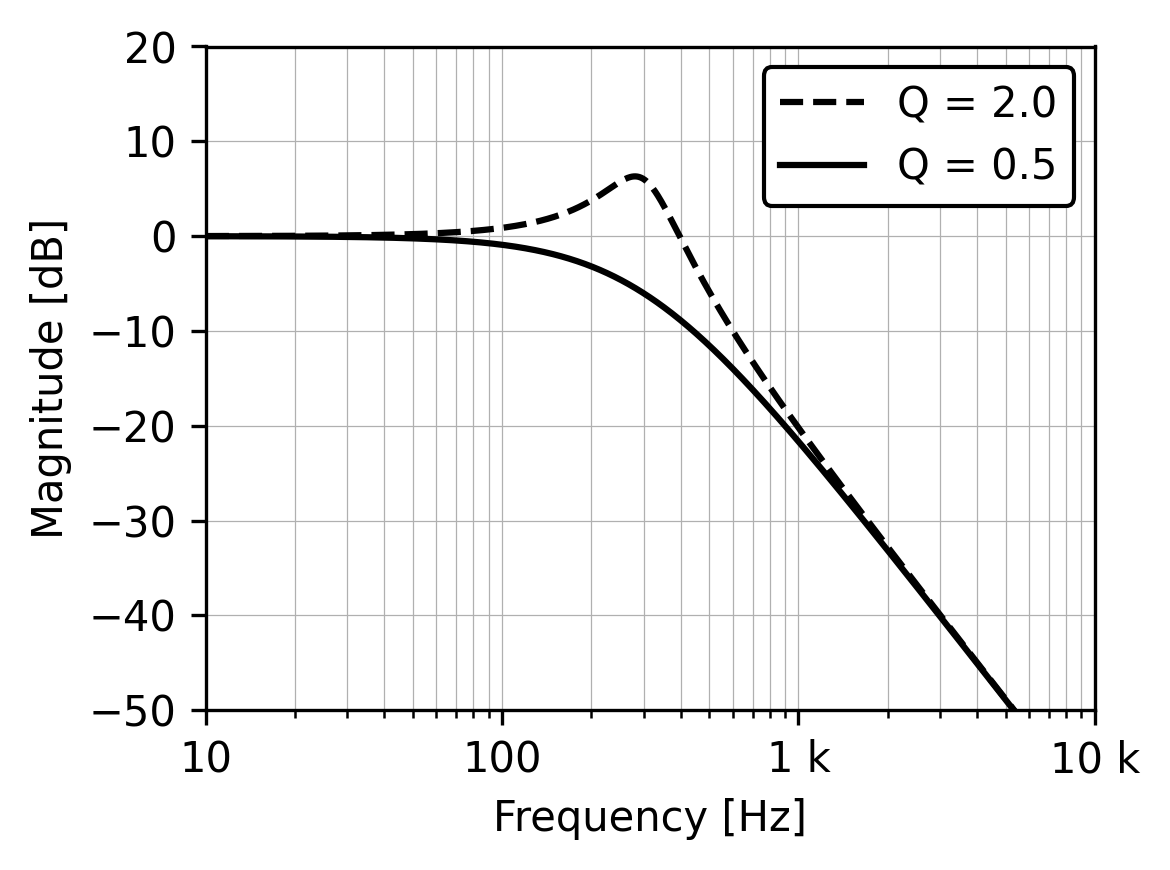

In [5]:
import numpy as np, matplotlib.pyplot as plt
from scipy import signal
from matplotlib.ticker import EngFormatter

# Parameters
plt_fmin = 1		# 10^fmax
plt_fmax = 4		# 10^fmin
f0 = 300
w0 = 2 * np.pi * f0
freq = np.logspace(plt_fmin, plt_fmax, 1000) # Hz
w = 2 * np.pi * freq

cases = [
	(2.0, "--", "Q = 2.0"),
	(0.5, "-", "Q = 0.5"),
]
plt.figure(figsize=(4, 3), dpi=300)
fmt = EngFormatter(places=0)

for Q, style, label in cases:
	sys = signal.TransferFunction([w0**2], [1, w0/Q, w0**2])
	_, mag, _ = signal.bode(sys, w)
	plt.semilogx(freq, mag, style, color="black", linewidth=1.5, label=label)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.xlim(10**plt_fmin, 10**plt_fmax)
plt.ylim(-50, 20)
plt.grid(True, which="both", linewidth=0.3)
plt.legend(framealpha=1, edgecolor="black")
ax = plt.gca()
ax.xaxis.set_major_formatter(fmt)
plt.tight_layout()
plt.show()

# Step Response

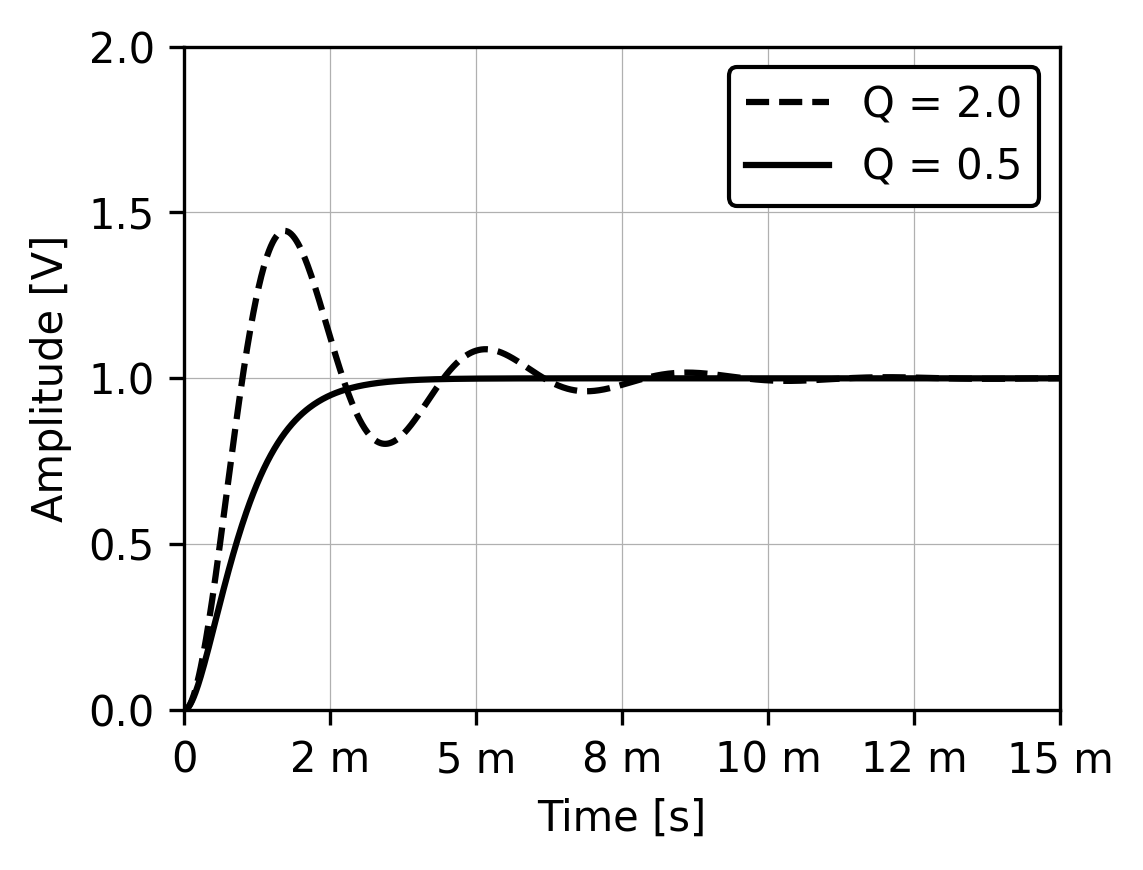

In [10]:
import numpy as np, matplotlib.pyplot as plt
from scipy import signal
from matplotlib.ticker import EngFormatter

# Parameters
plt_tmax = 15e-3
f0 = 300
w0 = 2 * np.pi * f0
t = np.linspace(0, plt_tmax, 1000)

cases = [
	(2.0, "--", "Q = 2.0"),
	(0.5, "-", "Q = 0.5"),
]
plt.figure(figsize=(4, 3), dpi=300)
fmt = EngFormatter(places=0)

for Q, style, label in cases:
	sys = signal.TransferFunction([w0**2], [1, w0/Q, w0**2])
	_, y = signal.step(sys, T=t)
	plt.plot(t, y, style, color="black", linewidth=1.5, label=label)

plt.xlabel("Time [s]")
plt.ylabel("Amplitude [V]")
plt.xlim(0, plt_tmax)
plt.ylim(0, 2)
plt.grid(True, linewidth=0.3)
plt.legend(framealpha=1, edgecolor="black")
ax = plt.gca()
ax.xaxis.set_major_formatter(fmt)
plt.tight_layout()
plt.show()